# Comparison: Two-Stage with Sonnet Re-eval (0408) vs Without (0407)

Does adding a Sonnet re-evaluation step to the Haiku + Kimi pipeline improve quality?

In [1]:
import sys
sys.path.insert(0, '../citator-pipeline')

import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, classification_report, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

from utils.eval_utils import evaluate_example

## Run Evaluation on Both Pipelines

0407: Haiku + Kimi (no re-eval)
Instruction Length (char):  20646

=== Overall Statistics ===
Total number of citing cases:  9
Total number of input tokens:  133292
Total number of output tokens:  19971
Total latency (ms):  114866

=== Evaluation Statistics ===
Using post-processed results: ../experiments_04072026/data/output/final_results.csv
Number of results in both model & expert labels:  288
Number of results with both model and expert treatment:  267
Number of results from model not in expert labels:  7
Number of expert labels missed by model:  4

=== Evaluation Metrics on Matched Results with Treatment ===

=== Overall Severity ===
              precision    recall  f1-score   support

     Caution       0.82      0.67      0.74        21
     Neutral       0.69      0.83      0.75        24
        Stop       0.92      1.00      0.96        11
     Warning       0.00      0.00      0.00         2

    accuracy                           0.78        58
   macro avg       0.61    

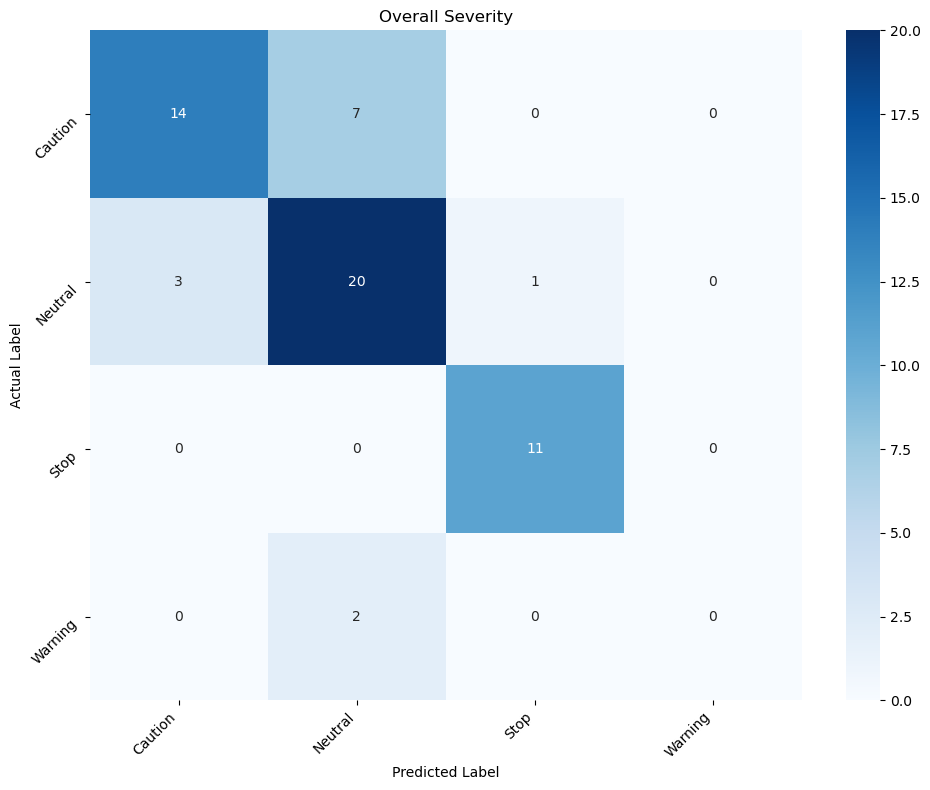


=== Overall Direction ===
                   precision    recall  f1-score   support

 Citing Reference       0.92      0.85      0.88        27
   Direct History       1.00      1.00      1.00         5
Related Reference       0.86      0.92      0.89        26

         accuracy                           0.90        58
        macro avg       0.93      0.92      0.92        58
     weighted avg       0.90      0.90      0.90        58


--- FP, FN, TP by class (Overall Direction) ---
      Class Label  FP  FN  TP
 Citing Reference   2   4  23
   Direct History   0   0   5
Related Reference   4   2  24

--- Confusion Matrix (Overall Direction) ---


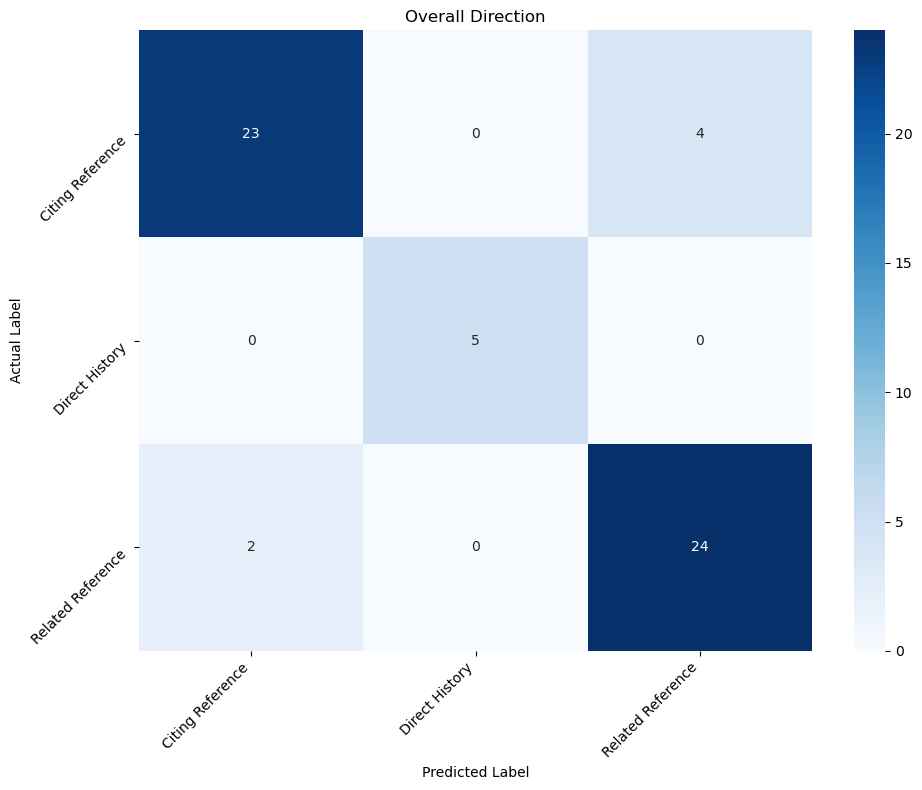


=== Treatment Evaluation ===
                                        precision    recall  f1-score   support

             Affirmed as recognized by       0.50      0.50      0.50         2
                           Affirmed by       1.00      1.00      1.00         1
         Cert. denied as recognized by       0.88      1.00      0.93        14
                              Cited by       0.20      0.29      0.24         7
                        Disapproved by       0.00      0.00      0.00         1
        Distinguished as recognized by       1.00      1.00      1.00         3
                      Distinguished by       0.79      0.61      0.69        18
                            Limited by       0.00      0.00      0.00         1
            Overruled as recognized by       0.83      0.83      0.83         6
                          Overruled by       0.00      0.00      0.00         0
Reversed and remanded as recognized by       1.00      1.00      1.00         1
         

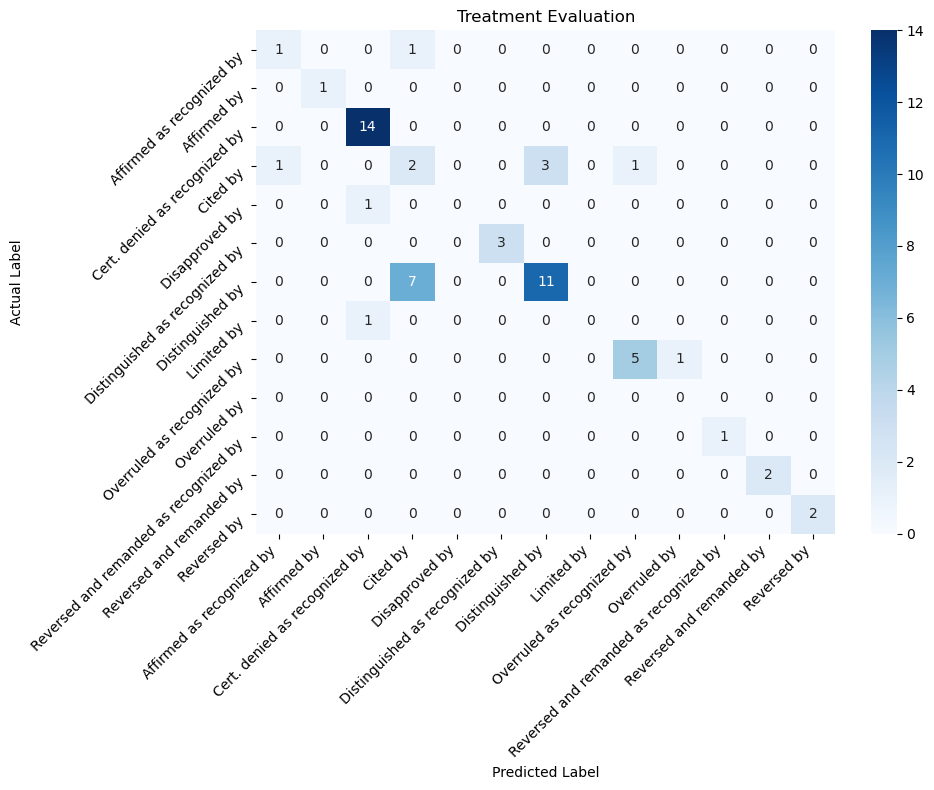

In [2]:
labels_path = '../data/benchmark_original/0410.csv'

print('=' * 80)
print('0407: Haiku + Kimi (no re-eval)')
print('=' * 80)
evaluate_example(
    output_dir='../experiments_04072026/data/output',
    eval_dir='../experiments_04072026/data/eval',
    labels_path=labels_path,
)

0408: Haiku + Kimi + Sonnet re-eval
Instruction Length (char):  20646

=== Overall Statistics ===
Total number of citing cases:  9
Total number of input tokens:  133292
Total number of output tokens:  20020
Total latency (ms):  100169

=== Evaluation Statistics ===
Using post-processed results: data/output/final_results.csv
Number of results in both model & expert labels:  290
Number of results with both model and expert treatment:  269
Number of results from model not in expert labels:  9
Number of expert labels missed by model:  2

=== Evaluation Metrics on Matched Results with Treatment ===

=== Overall Severity ===
              precision    recall  f1-score   support

     Caution       0.70      0.67      0.68        21
     Neutral       0.70      0.76      0.73        25
        Stop       0.92      1.00      0.96        12
     Warning       0.00      0.00      0.00         2

    accuracy                           0.75        60
   macro avg       0.58      0.61      0.59    

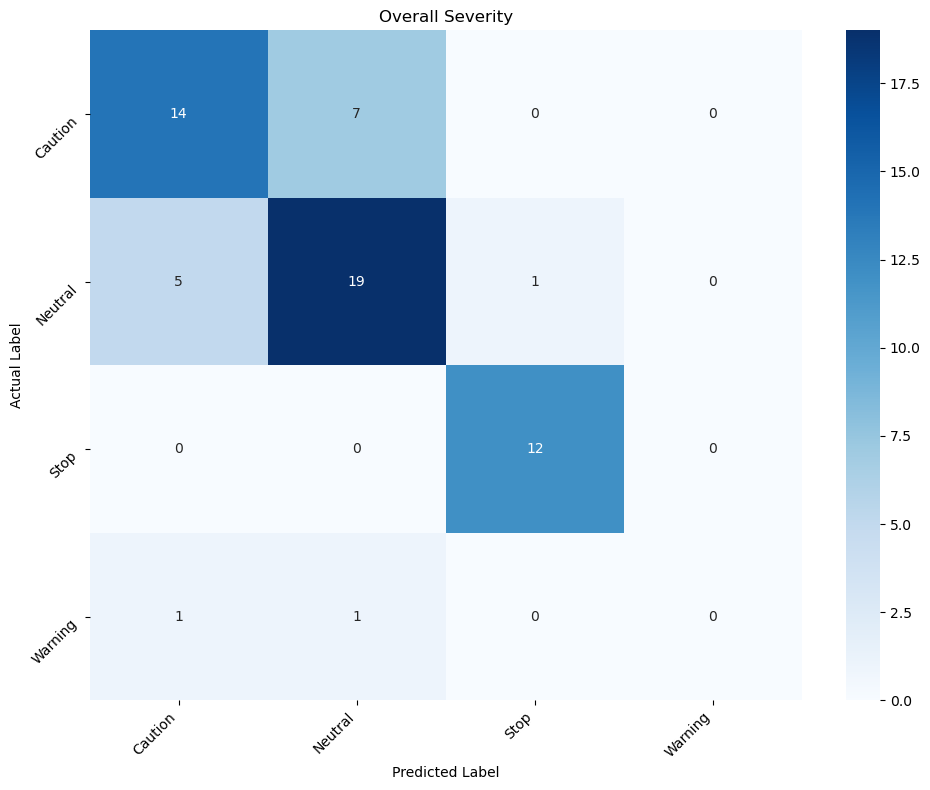


=== Overall Direction ===
                   precision    recall  f1-score   support

 Citing Reference       0.89      0.89      0.89        28
   Direct History       0.83      1.00      0.91         5
Related Reference       0.88      0.85      0.87        27

         accuracy                           0.88        60
        macro avg       0.87      0.91      0.89        60
     weighted avg       0.88      0.88      0.88        60


--- FP, FN, TP by class (Overall Direction) ---
      Class Label  FP  FN  TP
 Citing Reference   3   3  25
   Direct History   1   0   5
Related Reference   3   4  23

--- Confusion Matrix (Overall Direction) ---


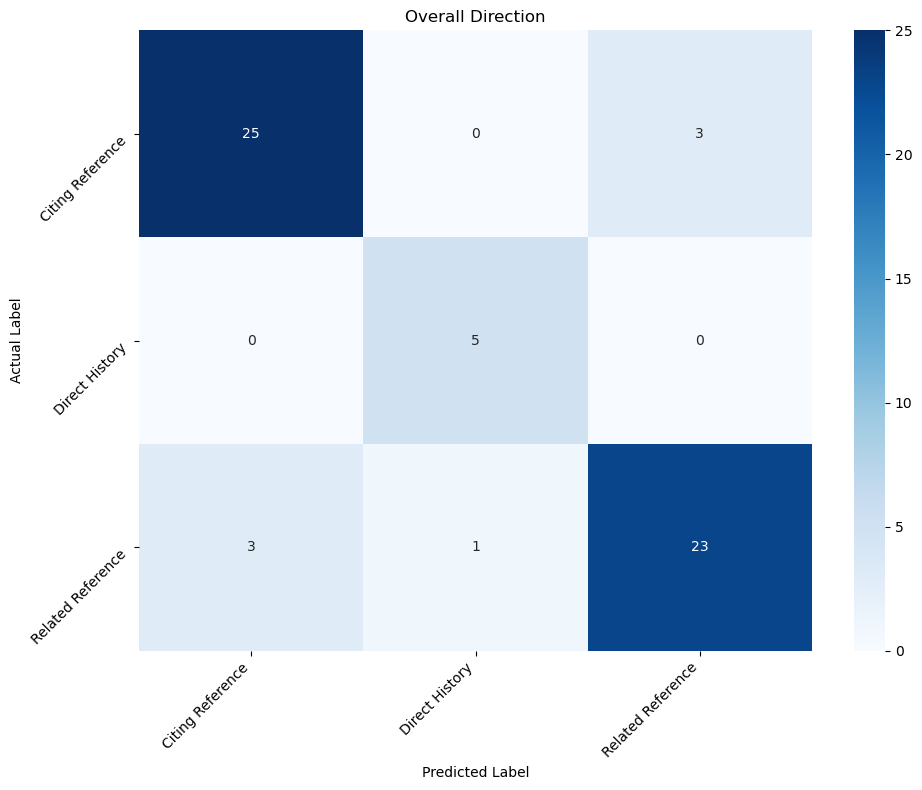


=== Treatment Evaluation ===
                                        precision    recall  f1-score   support

             Affirmed as recognized by       0.00      0.00      0.00         2
                           Affirmed by       0.50      1.00      0.67         1
         Cert. denied as recognized by       0.86      0.86      0.86        14
                              Cited by       0.18      0.25      0.21         8
                        Disapproved by       0.00      0.00      0.00         1
        Distinguished as recognized by       1.00      1.00      1.00         3
                      Distinguished by       0.65      0.61      0.63        18
                            Limited by       0.00      0.00      0.00         1
            Overruled as recognized by       0.88      1.00      0.93         7
Reversed and remanded as recognized by       1.00      1.00      1.00         1
              Reversed and remanded by       1.00      1.00      1.00         2
         

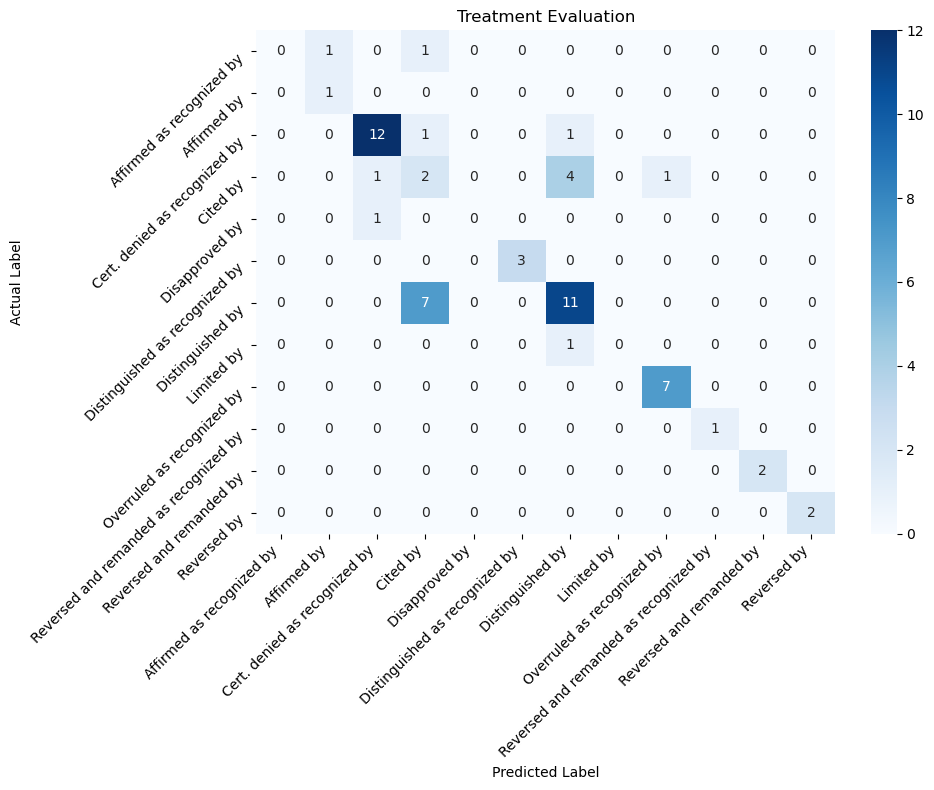

In [3]:
print('=' * 80)
print('0408: Haiku + Kimi + Sonnet re-eval')
print('=' * 80)
evaluate_example(
    output_dir='data/output',
    eval_dir='data/eval',
    labels_path=labels_path,
)

## Completeness Comparison

In [4]:
m07 = pd.read_csv('../experiments_04072026/data/eval/matched_results.csv')
m08 = pd.read_csv('data/eval/matched_results.csv')
mm07 = pd.read_csv('../experiments_04072026/data/eval/model_missed.csv')
mm08 = pd.read_csv('data/eval/model_missed.csv')
f07 = pd.read_csv('../experiments_04072026/data/output/final_results.csv')
f08 = pd.read_csv('data/output/final_results.csv')

completeness = pd.DataFrame([
    {'Pipeline': '0407 Haiku + Kimi',
     'Final Predictions': len(f07),
     'Matched': len(m07),
     'Model Missed': len(mm07),
     'Match Rate': f'{len(m07)/(len(m07)+len(mm07))*100:.2f}%'},
    {'Pipeline': '0408 Haiku + Kimi + Sonnet',
     'Final Predictions': len(f08),
     'Matched': len(m08),
     'Model Missed': len(mm08),
     'Match Rate': f'{len(m08)/(len(m08)+len(mm08))*100:.2f}%'},
])
print(completeness.to_string(index=False))

                  Pipeline  Final Predictions  Matched  Model Missed Match Rate
         0407 Haiku + Kimi                336      288             4     98.63%
0408 Haiku + Kimi + Sonnet                340      290             2     99.32%


## Quality Comparison

In [5]:
def compute_metrics(eval_dir):
    """Compute F1 metrics with Cited by downsampling."""
    mwt = pd.read_csv(f'{eval_dir}/matched_with_treatment.csv')
    df = mwt.copy()
    cited_mask = (df['predicted_treatment'] == 'Cited by') & (df['label_treatment'] == 'Cited by')
    non_cited = df[~cited_mask]
    sampled = df[cited_mask].sample(frac=0.01, random_state=42)
    df = pd.concat([non_cited, sampled], ignore_index=True)

    results = {}
    for name, true_col, pred_col in [
        ('severity', 'label_severity', 'predicted_severity'),
        ('direction', 'label_direction', 'predicted_direction'),
        ('treatment', 'label_treatment', 'predicted_treatment'),
    ]:
        mask = df[true_col].notna() & df[pred_col].notna()
        sub = df[mask]
        results[f'{name}_macro'] = f1_score(sub[true_col], sub[pred_col], average='macro')
        results[f'{name}_weighted'] = f1_score(sub[true_col], sub[pred_col], average='weighted')
    return results

m07_metrics = compute_metrics('../experiments_04072026/data/eval')
m08_metrics = compute_metrics('data/eval')

quality = pd.DataFrame([
    {'Metric': 'Severity (macro)', '0407': f'{m07_metrics["severity_macro"]:.2f}', '0408': f'{m08_metrics["severity_macro"]:.2f}'},
    {'Metric': 'Severity (weighted)', '0407': f'{m07_metrics["severity_weighted"]:.2f}', '0408': f'{m08_metrics["severity_weighted"]:.2f}'},
    {'Metric': 'Direction (macro)', '0407': f'{m07_metrics["direction_macro"]:.2f}', '0408': f'{m08_metrics["direction_macro"]:.2f}'},
    {'Metric': 'Direction (weighted)', '0407': f'{m07_metrics["direction_weighted"]:.2f}', '0408': f'{m08_metrics["direction_weighted"]:.2f}'},
    {'Metric': 'Treatment (macro)', '0407': f'{m07_metrics["treatment_macro"]:.2f}', '0408': f'{m08_metrics["treatment_macro"]:.2f}'},
    {'Metric': 'Treatment (weighted)', '0407': f'{m07_metrics["treatment_weighted"]:.2f}', '0408': f'{m08_metrics["treatment_weighted"]:.2f}'},
])
print(quality.to_string(index=False))

              Metric 0407 0408
    Severity (macro) 0.61 0.59
 Severity (weighted) 0.76 0.74
   Direction (macro) 0.92 0.89
Direction (weighted) 0.90 0.88
   Treatment (macro) 0.63 0.61
Treatment (weighted) 0.73 0.67


## Per-Treatment F1 Comparison

In [6]:
def per_treatment_f1(eval_dir):
    mwt = pd.read_csv(f'{eval_dir}/matched_with_treatment.csv')
    df = mwt.copy()
    cited_mask = (df['predicted_treatment'] == 'Cited by') & (df['label_treatment'] == 'Cited by')
    non_cited = df[~cited_mask]
    sampled = df[cited_mask].sample(frac=0.01, random_state=42)
    df = pd.concat([non_cited, sampled], ignore_index=True)

    labels = sorted(set(df['label_treatment'].unique()) | set(df['predicted_treatment'].unique()))
    p, r, f, s = precision_recall_fscore_support(df['label_treatment'], df['predicted_treatment'], labels=labels, zero_division=0)
    return pd.DataFrame({'treatment': labels, 'precision': p, 'recall': r, 'f1': f, 'support': s})

t07 = per_treatment_f1('../experiments_04072026/data/eval').set_index('treatment')
t08 = per_treatment_f1('data/eval').set_index('treatment')

all_treatments = sorted(set(t07.index) | set(t08.index))
comparison = pd.DataFrame({
    'treatment': all_treatments,
    '0407_f1': [t07.loc[t, 'f1'] if t in t07.index else np.nan for t in all_treatments],
    '0408_f1': [t08.loc[t, 'f1'] if t in t08.index else np.nan for t in all_treatments],
    'support_0407': [int(t07.loc[t, 'support']) if t in t07.index else 0 for t in all_treatments],
    'support_0408': [int(t08.loc[t, 'support']) if t in t08.index else 0 for t in all_treatments],
})
comparison['delta'] = comparison['0408_f1'] - comparison['0407_f1']
comparison = comparison.sort_values('support_0407', ascending=False)
print(comparison.to_string(index=False, float_format='%.2f'))

                             treatment  0407_f1  0408_f1  support_0407  support_0408  delta
                      Distinguished by     0.69     0.63            18            18  -0.06
         Cert. denied as recognized by     0.93     0.86            14            14  -0.08
                              Cited by     0.24     0.21             7             8  -0.02
            Overruled as recognized by     0.83     0.93             6             7   0.10
        Distinguished as recognized by     1.00     1.00             3             3   0.00
             Affirmed as recognized by     0.50     0.00             2             2  -0.50
              Reversed and remanded by     1.00     1.00             2             2   0.00
                           Reversed by     1.00     1.00             2             2   0.00
                           Affirmed by     1.00     0.67             1             1  -0.33
                        Disapproved by     0.00     0.00             1          

## Misclassification Patterns

In [7]:
def misclassifications(eval_dir, name):
    mwt = pd.read_csv(f'{eval_dir}/matched_with_treatment.csv')
    mis = mwt[mwt['label_treatment'] != mwt['predicted_treatment']]
    patterns = mis.groupby(['label_treatment', 'predicted_treatment']).size().sort_values(ascending=False)
    print(f'\n{name}: {len(mis)} total misclassifications')
    for (label, pred), count in patterns.head(10).items():
        print(f'  {label:45s} -> {pred:45s}: {count}')

misclassifications('../experiments_04072026/data/eval', '0407 Haiku + Kimi')
misclassifications('data/eval', '0408 Haiku + Kimi + Sonnet re-eval')


0407 Haiku + Kimi: 16 total misclassifications
  Distinguished by                              -> Cited by                                     : 7
  Cited by                                      -> Distinguished by                             : 3
  Affirmed as recognized by                     -> Cited by                                     : 1
  Cited by                                      -> Affirmed as recognized by                    : 1
  Cited by                                      -> Overruled as recognized by                   : 1
  Disapproved by                                -> Cert. denied as recognized by                : 1
  Limited by                                    -> Cert. denied as recognized by                : 1
  Overruled as recognized by                    -> Overruled by                                 : 1

0408 Haiku + Kimi + Sonnet re-eval: 19 total misclassifications
  Distinguished by                              -> Cited by                            

## Re-evaluation Impact Analysis

What did the Sonnet re-evaluator actually change?

In [8]:
import os

reeval_path = 'data/output/reevaluated_results.csv'
parsed_path = 'data/output/parsed_results.csv'

if os.path.exists(reeval_path) and os.path.exists(parsed_path):
    reeval = pd.read_csv(reeval_path)
    parsed = pd.read_csv(parsed_path)

    # Find rows where treatment changed
    changed = reeval[reeval['rationale'].fillna('').str.startswith('[Re-evaluated]')]
    print(f'Re-evaluated rows that changed treatment: {len(changed)}')
    print(f'\nChanges made:')
    for _, r in changed.iterrows():
        print(f'  {r["mainCitationString"]:25s} -> {r["treatment"]}')
else:
    print('Re-evaluation results not found')

Re-evaluated rows that changed treatment: 50

Changes made:
  466 F.Supp. 514           -> Reversed and remanded as recognized by
  214 F.2d 862              -> Overruled as recognized by
  297 U.S. 638              -> Overruled as recognized by
  365 U.S. 167              -> Overruled as recognized by
  16 Pet. 1                 -> Overruled as recognized by
  392 U.S. 183              -> Overruled as recognized by
  16 Pet. 1                 -> Overruled as recognized by
  163 U.S. 537              -> Overruled as recognized by
  310 U.S. 586              -> Overruled as recognized by
  222 U.S. 370              -> Distinguished by
  270 U.S. 87               -> Distinguished by
  177 U.S. 214              -> Distinguished by
  250 U.S. 566              -> Distinguished by
  439 F.2d 1285             -> Distinguished by
  234 U.S. 149              -> Distinguished by
  586 So.2d 685             -> Distinguished by
  295 U.S. 495              -> Distinguished by
  735 F.2d 725        

## Cost Comparison

In [9]:
r07_ext = pd.read_csv('../experiments_04072026/data/output/extraction_raw_results.csv')
r07_cls = pd.read_csv('../experiments_04072026/data/output/classification_raw_results.csv')
r08_ext = pd.read_csv('data/output/extraction_raw_results.csv')
r08_cls = pd.read_csv('data/output/classification_raw_results.csv')

haiku07 = r07_ext['input_tokens'].sum() * 0.80/1e6 + r07_ext['output_tokens'].sum() * 4/1e6
kimi07 = r07_cls['input_tokens'].sum() * 0.15/1e6 + r07_cls['output_tokens'].sum() * 0.60/1e6
haiku08 = r08_ext['input_tokens'].sum() * 0.80/1e6 + r08_ext['output_tokens'].sum() * 4/1e6
kimi08 = r08_cls['input_tokens'].sum() * 0.15/1e6 + r08_cls['output_tokens'].sum() * 0.60/1e6

n_cases = len(r07_ext)

reeval_csv = 'data/output/reevaluation_raw_results.csv'
sonnet_reeval = 0
if os.path.exists(reeval_csv):
    r08_reeval = pd.read_csv(reeval_csv)
    sonnet_reeval = r08_reeval['input_tokens'].sum() * 3/1e6 + r08_reeval['output_tokens'].sum() * 15/1e6

total_07 = haiku07 + kimi07
total_08 = haiku08 + kimi08 + sonnet_reeval

cost_df = pd.DataFrame([
    {'Component': '0407 Haiku extraction', 'Cost': f'${haiku07:.3f}', 'Per Case': f'${haiku07/n_cases:.3f}'},
    {'Component': '0407 Kimi classification', 'Cost': f'${kimi07:.3f}', 'Per Case': f'${kimi07/n_cases:.3f}'},
    {'Component': '0407 Total', 'Cost': f'${total_07:.3f}', 'Per Case': f'${total_07/n_cases:.3f}'},
    {'Component': '', 'Cost': '', 'Per Case': ''},
    {'Component': '0408 Haiku extraction', 'Cost': f'${haiku08:.3f}', 'Per Case': f'${haiku08/n_cases:.3f}'},
    {'Component': '0408 Kimi classification', 'Cost': f'${kimi08:.3f}', 'Per Case': f'${kimi08/n_cases:.3f}'},
    {'Component': '0408 Sonnet re-eval', 'Cost': f'${sonnet_reeval:.3f}', 'Per Case': f'${sonnet_reeval/n_cases:.3f}'},
    {'Component': '0408 Total', 'Cost': f'${total_08:.3f}', 'Per Case': f'${total_08/n_cases:.3f}'},
])
print(cost_df.to_string(index=False))
print(f'\nRe-eval overhead: +{(total_08/total_07 - 1)*100:.0f}%')

               Component   Cost Per Case
   0407 Haiku extraction $0.187   $0.021
0407 Kimi classification $0.241   $0.027
              0407 Total $0.428   $0.048
                                        
   0408 Haiku extraction $0.187   $0.021
0408 Kimi classification $0.238   $0.026
     0408 Sonnet re-eval $0.681   $0.076
              0408 Total $1.106   $0.123

Re-eval overhead: +158%


## Summary

In [10]:
summary = pd.DataFrame([
    {'Dimension': 'Match Rate',
     '0407 Haiku+Kimi': f'{len(m07)/(len(m07)+len(mm07))*100:.2f}%',
     '0408 +Sonnet re-eval': f'{len(m08)/(len(m08)+len(mm08))*100:.2f}%'},
    {'Dimension': 'Severity F1 (macro)',
     '0407 Haiku+Kimi': f'{m07_metrics["severity_macro"]:.2f}',
     '0408 +Sonnet re-eval': f'{m08_metrics["severity_macro"]:.2f}'},
    {'Dimension': 'Severity F1 (weighted)',
     '0407 Haiku+Kimi': f'{m07_metrics["severity_weighted"]:.2f}',
     '0408 +Sonnet re-eval': f'{m08_metrics["severity_weighted"]:.2f}'},
    {'Dimension': 'Direction F1 (macro)',
     '0407 Haiku+Kimi': f'{m07_metrics["direction_macro"]:.2f}',
     '0408 +Sonnet re-eval': f'{m08_metrics["direction_macro"]:.2f}'},
    {'Dimension': 'Direction F1 (weighted)',
     '0407 Haiku+Kimi': f'{m07_metrics["direction_weighted"]:.2f}',
     '0408 +Sonnet re-eval': f'{m08_metrics["direction_weighted"]:.2f}'},
    {'Dimension': 'Treatment F1 (macro)',
     '0407 Haiku+Kimi': f'{m07_metrics["treatment_macro"]:.2f}',
     '0408 +Sonnet re-eval': f'{m08_metrics["treatment_macro"]:.2f}'},
    {'Dimension': 'Treatment F1 (weighted)',
     '0407 Haiku+Kimi': f'{m07_metrics["treatment_weighted"]:.2f}',
     '0408 +Sonnet re-eval': f'{m08_metrics["treatment_weighted"]:.2f}'},
    {'Dimension': 'Cost/Case',
     '0407 Haiku+Kimi': f'${total_07/n_cases:.3f}',
     '0408 +Sonnet re-eval': f'${total_08/n_cases:.3f}'},
])
print(summary.to_string(index=False))
print(f'\nConclusion: Sonnet re-evaluation does not improve quality and adds +{(total_08/total_07-1)*100:.0f}% cost.')
print('Recommendation: use 0407 (no re-evaluation) as the production configuration.')

              Dimension 0407 Haiku+Kimi 0408 +Sonnet re-eval
             Match Rate          98.63%               99.32%
    Severity F1 (macro)            0.61                 0.59
 Severity F1 (weighted)            0.76                 0.74
   Direction F1 (macro)            0.92                 0.89
Direction F1 (weighted)            0.90                 0.88
   Treatment F1 (macro)            0.63                 0.61
Treatment F1 (weighted)            0.73                 0.67
              Cost/Case          $0.048               $0.123

Conclusion: Sonnet re-evaluation does not improve quality and adds +158% cost.
Recommendation: use 0407 (no re-evaluation) as the production configuration.
